# Определение стоимости автомобилей

Сервис по продаже автомобилей с пробегом «Не бит, не крашен» разрабатывает приложение для привлечения новых клиентов. В нём можно быстро узнать рыночную стоимость своего автомобиля. В вашем распоряжении исторические данные: технические характеристики, комплектации и цены автомобилей. Вам нужно построить модель для определения стоимости. 

Заказчику важны:

- качество предсказания;
- скорость предсказания;
- время обучения.

**Описание данных**



**Признаки**

DateCrawled — дата скачивания анкеты из базы

VehicleType — тип автомобильного кузова

RegistrationYear — год регистрации автомобиля

Gearbox — тип коробки передач

Power — мощность (л. с.)

Model — модель автомобиля

Kilometer — пробег (км)

RegistrationMonth — месяц регистрации автомобиля

FuelType — тип топлива

Brand — марка автомобиля

Repaired — была машина в ремонте или нет

DateCreated — дата создания анкеты

NumberOfPictures — количество фотографий автомобиля

PostalCode — почтовый индекс владельца анкеты (пользователя)

LastSeen — дата последней активности пользователя



**Целевой признак**


Price — цена (евро)

## Подготовка данных

In [1]:
!pip install scikit-learn==1.1.3

     |████████████████████████████████| 30.8 MB 50 kB/s  eta 0:00:01
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 0.24.1
    Uninstalling scikit-learn-0.24.1:
      Successfully uninstalled scikit-learn-0.24.1


In [2]:
# Библиотеки 

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from catboost import CatBoostRegressor
from catboost import CatBoostClassifier
from lightgbm import LGBMRegressor
from sklearn.model_selection import GridSearchCV

from sklearn.compose import make_column_transformer
from sklearn.preprocessing import (
    OneHotEncoder,
    OrdinalEncoder,
    StandardScaler
)

In [3]:
df = pd.read_csv('/datasets/autos.csv')
display(df.head(10))
print(df.info())

,DateCrawled,Price,VehicleType,RegistrationYear,Gearbox,Power,Model,Kilometer,RegistrationMonth,FuelType,Brand,Repaired,DateCreated,NumberOfPictures,PostalCode,LastSeen
0,2016-03-24 11:52:17,480,NaN,1993,manual,0,golf,150000,0,petrol,volkswagen,NaN,2016-03-24 00:00:00,0,70435,2016-04-07 03:16:57
1,2016-03-24 10:58:45,18300,coupe,2011,manual,190,NaN,125000,5,gasoline,audi,yes,2016-03-24 00:00:00,0,66954,2016-04-07 01:46:50
2,2016-03-14 12:52:21,9800,suv,2004,auto,163,grand,125000,8,gasoline,jeep,NaN,2016-03-14 00:00:00,0,90480,2016-04-05 12:47:46
3,2016-03-17 16:54:04,1500,small,2001,manual,75,golf,150000,6,petrol,volkswagen,no,2016-03-17 00:00:00,0,91074,2016-03-17 17:40:17
4,2016-03-31 17:25:20,3600,small,2008,manual,69,fabia,90000,7,gasoline,skoda,no,2016-03-31 00:00:00,0,60437,2016-04-06 10:17:21
5,2016-04-04 17:36:23,650,sedan,1995,manual,102,3er,150000,10,petrol,bmw,yes,2016-04-04 00:00:00,0,33775,2016-04-06 19:17:07
6,2016-04-01 20:48:51,2200,convertible,2004,manual,109,2_reihe,150000,8,petrol,peugeot,no,2016-04-01 00:00:00,0,67112,2016-04-05 18:18:39
7,2016-03-21 18:54:38,0,sedan,1980,manual,50,other,40000,7,petrol,volkswagen,no,2016-03-21 00:00:00,0,19348,2016-03-25 16:47:58
8,2016-04-04 23:42:13,14500,bus,2014,manual,125,c_max,30000,8,petrol,ford,NaN,2016-04-04 00:00:00,0,94505,2016-04-04 23:42:13
9,2016-03-17 10:53:50,999,small,1998,manual,101,golf,150000,0,NaN,volkswagen,NaN,2016-03-17 00:00:00,0,27472,2016-03-31 17:17:06


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 354369 entries, 0 to 354368
Data columns (total 16 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   DateCrawled        354369 non-null  object
 1   Price              354369 non-null  int64 
 2   VehicleType        316879 non-null  object
 3   RegistrationYear   354369 non-null  int64 
 4   Gearbox            334536 non-null  object
 5   Power              354369 non-null  int64 
 6   Model              334664 non-null  object
 7   Kilometer          354369 non-null  int64 
 8   RegistrationMonth  354369 non-null  int64 
 9   FuelType           321474 non-null  object
 10  Brand              354369 non-null  object
 11  Repaired           283215 non-null  object
 12  DateCreated        354369 non-null  object
 13  NumberOfPictures   354369 non-null  int64 
 14  PostalCode         354369 non-null  int64 
 15  LastSeen           354369 non-null  object
dtypes: int64(7), object(

In [4]:
print(df['RegistrationYear'].describe())

print(df['DateCrawled'].describe())

count    354369.000000
mean       2004.234448
std          90.227958
min        1000.000000
25%        1999.000000
50%        2003.000000
75%        2008.000000
max        9999.000000
Name: RegistrationYear, dtype: float64
count                  354369
unique                 271174
top       2016-03-24 14:49:47
freq                        7
Name: DateCrawled, dtype: object


In [5]:
# Избавимся от ненужных признаков
df.drop(columns=['DateCrawled', 'RegistrationMonth', 
                 'DateCreated', 'PostalCode', 'LastSeen', 'NumberOfPictures'], axis=1, inplace=True)
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 354369 entries, 0 to 354368
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   Price             354369 non-null  int64 
 1   VehicleType       316879 non-null  object
 2   RegistrationYear  354369 non-null  int64 
 3   Gearbox           334536 non-null  object
 4   Power             354369 non-null  int64 
 5   Model             334664 non-null  object
 6   Kilometer         354369 non-null  int64 
 7   FuelType          321474 non-null  object
 8   Brand             354369 non-null  object
 9   Repaired          283215 non-null  object
dtypes: int64(4), object(6)
memory usage: 27.0+ MB
None


In [6]:
# Пропуски
df.isna().sum()

Price                   0
VehicleType         37490
RegistrationYear        0
Gearbox             19833
Power                   0
Model               19705
Kilometer               0
FuelType            32895
Brand                   0
Repaired            71154
dtype: int64

По итогу первого взгляда на данные были исключены признаки, нерелевантные для дальнейшего анализа.

**Работа с выбросами и изучение каждого признака**

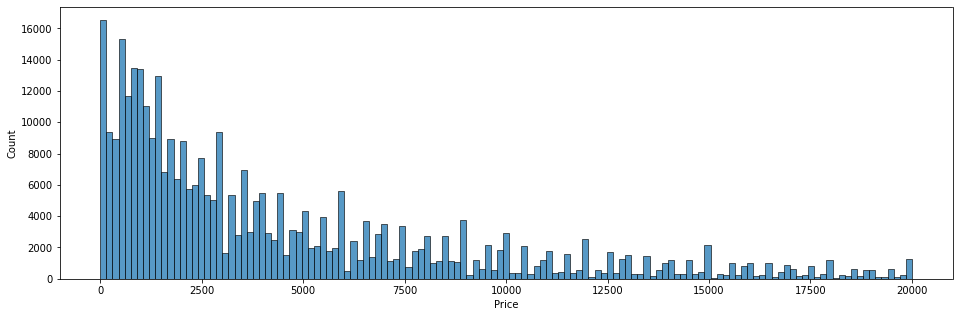

count    354369.000000
mean       4416.656776
std        4514.158514
min           0.000000
25%        1050.000000
50%        2700.000000
75%        6400.000000
max       20000.000000
Name: Price, dtype: float64

In [7]:
# Анализ цены
ax = df['Price']
plt.figure(figsize=(16,5))
sns.histplot(ax)
plt.show()

df['Price'].describe()

In [8]:
# Уберем слишком маленькие цены
df = df[df['Price'] > 50]

In [9]:
# Анализ даты выпуска
print(df['RegistrationYear'].value_counts(dropna=False))
df['RegistrationYear'].describe()

2000    22761
1999    21871
2005    21389
2006    19648
2001    19584
        ...  
1949        1
2222        1
5300        1
8888        1
2290        1
Name: RegistrationYear, Length: 139, dtype: int64


count    341619.000000
mean       2004.035627
std          74.620972
min        1000.000000
25%        1999.000000
50%        2003.000000
75%        2008.000000
max        9999.000000
Name: RegistrationYear, dtype: float64

In [10]:
# Уберем года, не имеющие смысла
df = df.query('1945 < RegistrationYear < 2016')
df['RegistrationYear'].describe()

count    318900.000000
mean       2002.269150
std           6.444523
min        1946.000000
25%        1999.000000
50%        2003.000000
75%        2007.000000
max        2015.000000
Name: RegistrationYear, dtype: float64

In [11]:
# Анализ и очистка данных мощности 
df['Power'].describe()
df = df.query('20 < Power < 350')

In [12]:
df['VehicleType'].value_counts(dropna=False)

sedan          82477
small          69578
wagon          58971
bus            26148
convertible    18692
coupe          14384
suv            10822
NaN             4659
other           2396
Name: VehicleType, dtype: int64

In [13]:
df['Gearbox'].value_counts(dropna=False)

manual    226047
auto       57301
NaN         4779
Name: Gearbox, dtype: int64

In [14]:
df['FuelType'].value_counts(dropna=False)

petrol      183251
gasoline     86770
NaN          12739
lpg           4581
cng            474
hybrid         197
other           80
electric        35
Name: FuelType, dtype: int64

In [15]:
df['Repaired'].value_counts(dropna=False)

no     220664
NaN     39756
yes     27707
Name: Repaired, dtype: int64

In [16]:
# Проценты пропусков
def na (df):
    df_na = pd.DataFrame(df.isna().sum())
    df_na['percent'] = df_na[0] * 100 / len(df)
    return df_na[(df_na['percent'] > 0)].sort_values('percent', ascending = False)
display(na(df))

,0,percent
Repaired,39756,13.798082
FuelType,12739,4.421314
Model,10022,3.478327
Gearbox,4779,1.658644
VehicleType,4659,1.616995


In [17]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Int64Index: 288127 entries, 1 to 354368
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   Price             288127 non-null  int64 
 1   VehicleType       283468 non-null  object
 2   RegistrationYear  288127 non-null  int64 
 3   Gearbox           283348 non-null  object
 4   Power             288127 non-null  int64 
 5   Model             278105 non-null  object
 6   Kilometer         288127 non-null  int64 
 7   FuelType          275388 non-null  object
 8   Brand             288127 non-null  object
 9   Repaired          248371 non-null  object
dtypes: int64(4), object(6)
memory usage: 24.2+ MB
None


Были исключены выбросы из данных о цене, мощности и годе выпуска автомобилей. Так же были проанализированы все пропуски в данных (кол-во пропусков не превышает 15% ни в одном из столбцов).

**Работа с пропусками**

In [18]:
# Заменим gasoline на petrol 
df.loc[df['FuelType'] == 'gasoline', 'FuelType'] = 'petrol'
df['FuelType'].value_counts(dropna=False)


petrol      270021
NaN          12739
lpg           4581
cng            474
hybrid         197
other           80
electric        35
Name: FuelType, dtype: int64

In [19]:
# Заменим другие пропуска на unknown 
df['VehicleType'] = df['VehicleType'].fillna(value = 'unknown')
df['Gearbox'] = df['Gearbox'].fillna(value = 'unknown')
df['Model'] = df['Model'].fillna(value = 'unknown')
df['FuelType'] = df['FuelType'].fillna(value = 'unknown')
df['Repaired'] = df['Repaired'].fillna(value = 'unknown')

df.isna().sum()

Price               0
VehicleType         0
RegistrationYear    0
Gearbox             0
Power               0
Model               0
Kilometer           0
FuelType            0
Brand               0
Repaired            0
dtype: int64

Пропуска были заменены на значения unknown. Так же одинаковые значения были приведены к единому параметру.

Была совершена кодировка для данных столбцов - ['VehicleType', 'Gearbox', 'Model', 'FuelType', 'Brand', 'Repaired']

## Обучение моделей

In [20]:
# Деление на выборки

features = df.drop('Price', axis = 1)
target = df['Price']

features_train, features_test, target_train, target_test = train_test_split(
    features, target, test_size=0.4, random_state=12345)
# print (features_train.info())
# print (features_test.info())
ohe_features = features_train.select_dtypes(include='object').columns.to_list()
num_features = features_train.select_dtypes(exclude='object').columns.to_list()
# num_features.remove('Repaired')
print(num_features) 
print(ohe_features)

['RegistrationYear', 'Power', 'Kilometer']
['VehicleType', 'Gearbox', 'Model', 'FuelType', 'Brand', 'Repaired']


**Кодировка**

In [22]:

transformer = make_column_transformer(
    (
        OneHotEncoder(drop='first', handle_unknown='ignore'),
        ohe_features
    ),
    (
        StandardScaler(), 
        num_features
    ),
    remainder='passthrough',
    verbose_feature_names_out=False
)

# всё готово в пару строк кода
features_train_ohe = pd.DataFrame.sparse.from_spmatrix(
    transformer.fit_transform(features_train),
    columns=transformer.get_feature_names_out()
)



# трансформируем тестовую выборку
features_test_ohe = pd.DataFrame.sparse.from_spmatrix(
    transformer.transform(features_test),
    columns=transformer.get_feature_names_out()
)

features_test_ohe.head()

,VehicleType_convertible,VehicleType_coupe,VehicleType_other,VehicleType_sedan,VehicleType_small,VehicleType_suv,VehicleType_unknown,VehicleType_wagon,Gearbox_manual,Gearbox_unknown,...,Brand_suzuki,Brand_toyota,Brand_trabant,Brand_volkswagen,Brand_volvo,Repaired_unknown,Repaired_yes,RegistrationYear,Power,Kilometer
0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,-0.893262,-0.877969,0.594496
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,-0.732641,-0.199877,0.594496
2,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,-0.090156,-1.168580,0.594496
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.712950,0.962567,0.594496
4,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,-0.572020,-0.877969,0.594496


In [24]:
#Прямое кодирование
def encoder(X_train, X_test, columns):
    encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    encoder.fit(X_train[columns])
    X_train[columns] = encoder.transform(X_train[columns])
    X_test[columns] = encoder.transform(X_test[columns])
    return X_train, X_test

ordinal_features_train, ordinal_features_test = encoder(features_train, features_test, ['VehicleType', 'Gearbox', 'Model', 'FuelType', 'Brand', 'Repaired'])

# print (ordinal_features_train.head())
ordinal_features_test.head()

,VehicleType,RegistrationYear,Gearbox,Power,Model,Kilometer,FuelType,Brand,Repaired
119883,4.0,1997,1.0,75,116.0,150000,5.0,38.0,0.0
220317,8.0,1998,1.0,110,82.0,150000,5.0,36.0,0.0
66558,5.0,2002,1.0,60,128.0,150000,6.0,10.0,1.0
136133,8.0,2007,1.0,170,170.0,150000,5.0,38.0,0.0
93366,4.0,1999,1.0,75,116.0,150000,5.0,38.0,0.0


In [23]:
%%time
# Линейная с кросс валидацией
model = LinearRegression()
print('# Train for root_mean_squared_error')
print()
cv_RMSE_LR = (cross_val_score(model, 
                             features_train_ohe, 
                             target_train, 
                             cv=5, 
                             scoring='neg_mean_squared_error').mean() * -1) ** 0.5
print('Mean RMSE from CV of LinearRegression =', cv_RMSE_LR)


# Train for root_mean_squared_error

Mean RMSE from CV of LinearRegression = 2550.128374647628
CPU times: user 1min 16s, sys: 1min 31s, total: 2min 47s
Wall time: 2min 47s


In [ ]:
%%time
# LightGBM
model = LGBMRegressor() 
hyperparams = [{'num_leaves':[31, 100, 200], 
                'learning_rate':[0.1, 0.3, 0.5],
                'random_state':[12345]}]

model1 = GridSearchCV(model, hyperparams, scoring='neg_mean_squared_error')
model1.fit(ordinal_features_train, target_train)
print("Оптимальные параметры")
print()
print(model1.best_params_)
print()
means = model1.cv_results_['mean_test_score']
stds = model1.cv_results_['std_test_score']
for mean, std, params in zip(means, stds, model1.cv_results_['params']):
    print("%0.6f for %r"% ((mean*-1)** 0.5, params))
print()

cv_RMSE_LGBMR = (max(means)*-1) ** 0.5

После разделения данных по признакам и на обучающую и тестовую выборку были построены 2 модели - Линейная регрессия и LightGBM с градиентным бустингом. Кросс-валидация для линейной регрессии заняла меньше секунды. В то же время, подбор параметров для модели LightGBM занял почти 10 минут. Оптимальные параметры модели LightGBM - **'learning_rate': 0.3, 'num_leaves': 200**

## Анализ моделей

In [49]:
%%time
# Линейная
model = LinearRegression()
model.fit(features_train_ohe, target_train)

CPU times: user 15.1 s, sys: 15.1 s, total: 30.2 s
Wall time: 30.1 s


LinearRegression()

In [50]:
%%time
target_predict = model.predict(features_test_ohe)

final_RMSE_LR = mean_squared_error(target_test, target_predict) ** 0.5

print(final_RMSE_LR)

2567.9411738113477
CPU times: user 33.6 ms, sys: 0 ns, total: 33.6 ms
Wall time: 32.1 ms


In [23]:
%%time

model = LGBMRegressor(learning_rate=0.3, 
                      num_leaves=200, 
                      random_state=12345)
model.fit(ordinal_features_train, target_train)

CPU times: user 2min 23s, sys: 836 ms, total: 2min 24s
Wall time: 2min 25s


LGBMRegressor(learning_rate=0.3, num_leaves=200, random_state=12345)

In [24]:
%%time
target_predict = model.predict(ordinal_features_test)

final_RMSE_LGBMR = mean_squared_error(target_test, target_predict) ** 0.5
print(final_RMSE_LGBMR)

1529.7257697020298
CPU times: user 984 ms, sys: 23.1 ms, total: 1.01 s
Wall time: 935 ms


**Общий вывод**


После первоначального анализа данных была проведена их предобработка - мы избавились от ненужных признаков, выбросов (в цене, мощности и годе выпуска автомобиля), а так же заполнили пропуски в данных.
Затем было проведено кодирование данных. One hot encoding для модели линейной регрессии и ordinary encoding для LGBMR. 
После кросс-валидации линейной регрессии и подбора параметров для LGBMR (занимает большего всего времени), мы перешли к анализу моделей. Только LGBMR смогла показать удовлетварительный для заказчика результат (Значение метрики RMSE должно быть меньше 2500). Однако обучение LGBMR занимает в 5 раз больше времени чем линейной регресси (Непостредственное предсказание в обоих случаях занимает минимальное время). 

Таким образом LGBMR была выбрана как модель для заказчика